<a href="https://colab.research.google.com/github/zainbmaged/AI_datasciencetrack/blob/main/Assignment1nlpfollow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Download data and preprocessing

In [ ]:
from pathlib import Path
import os
DATA_PATH=Path('./dataset/')
DATA_PATH.mkdir(exist_ok=True)

if not os.path.exists('./dataset/aclImdb'):
    !curl -O http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
    !tar -xf aclImdb_v1.tar.gz -C {DATA_PATH}

In [ ]:
import tarfile

file_path = 'aclImdb_v1.tar.gz'
extract_path = './dataset/'

with tarfile.open(file_path, 'r:gz') as tar:
    tar.extractall(path=extract_path)

print(f"File extracted to {extract_path}")

/tmp/ipython-input-2864593206.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


File extracted to ./dataset/


In [ ]:
import numpy as np
CLASSES = ['neg', 'pos']#, 'unsup']
PATH=Path('./dataset/aclImdb/')

def get_texts(path):
    texts,labels = [],[]
    for idx,label in enumerate(CLASSES):

        for fname in (path/label).glob('*.*'):
            texts.append(fname.open('r', encoding='utf-8').read())
            labels.append(idx)
    return texts, labels

trn_texts,trn_labels = get_texts(PATH/'train')
tst_texts,tst_labels = get_texts(PATH/'test')

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')
stop_words = stopwords.words('english')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
import re
import string
import html
import unicodedata
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

def remove_special_chars(text):
    re1 = re.compile(r'[  ]+')
    x = html.unescape(text)

    x = x.replace(' @.@ ', '.')
    x = x.replace(' @-@ ', '-')
    x = x.replace('\\', ' \\ ')

    return re1.sub(' ', x)


def remove_non_ascii(text):
    """Remove non-ASCII characters from list of tokenized words"""
    return unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')


def to_lowercase(text):
    return text.lower()



def remove_punctuation(text):
    """Remove punctuation from list of tokenized words"""
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)


def replace_numbers(text):
    """Replace all interger occurrences in list of tokenized words with textual representation"""
    return re.sub(r'\d+', '', text)


def remove_whitespaces(text):
    return text.strip()


def remove_stopwords(words, stop_words):
    """
    :param words:
    :type words:
    :param stop_words: from sklearn.feature_extraction.stop_words import ENGLISH_STOP_WORDS
    or
    from spacy.lang.en.stop_words import STOP_WORDS
    :type stop_words:
    :return:
    :rtype:
    """
    return [word for word in words if word not in stop_words]


def stem_words(words):
    """Stem words in text"""
    stemmer = PorterStemmer()
    return [stemmer.stem(word) for word in words]

def lemmatize_words(words):
    """Lemmatize words in text"""

    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(word) for word in words]

def lemmatize_verbs(words):
    """Lemmatize verbs in text"""

    lemmatizer = WordNetLemmatizer()
    return ' '.join([lemmatizer.lemmatize(word, pos='v') for word in words])

def text2words(text):
  return word_tokenize(text)

def normalize_text( text):
    text = remove_special_chars(text)
    text = remove_non_ascii(text)
    text = remove_punctuation(text)
    text = to_lowercase(text)
    text = replace_numbers(text)
    words = text2words(text)
    words = remove_stopwords(words, stop_words)
    words = lemmatize_words(words)
    words = lemmatize_verbs(words)

    return ''.join(words)

In [ ]:
def normalize_corpus(corpus):
  return [normalize_text(t) for t in corpus]
tst_texts = normalize_corpus(tst_texts)
trn_texts = normalize_corpus(trn_texts)

In [ ]:
texts = trn_texts + tst_texts

# BoW with keras Tokenizer

## Examples

Doc 1: "good food, good service"

Doc 2: "good food, amazing food"

Doc 3: "bad service, bad food"

Doc 4: "amazing service, fast service"

Doc 5: "the food was amazing"

Vocabulary: ['amazing', 'bad', 'fast', 'food', 'good', 'service', 'the', 'was']

### Binary


|       | amazing | bad | fast | food | good | service | the | was |
|-------|---------|-----|------|------|------|---------|-----|-----|
| Doc 1 |    0    |  0  |  0   |  1   |  1   |    1    |  0  |  0  |
| Doc 2 |    1    |  0  |  0   |  1   |  1   |    0    |  0  |  0  |
| Doc 3 |    0    |  1  |  0   |  1   |  0   |    1    |  0  |  0  |
| Doc 4 |    1    |  0  |  1   |  0   |  0   |    1    |  0  |  0  |
| Doc 5 |    1    |  0  |  0   |  1   |  0   |    0    |  1  |  1  |




### Counts (TF)


|       | amazing | bad | fast | food | good | service | the | was |
|-------|---------|-----|------|------|------|---------|-----|-----|
| Doc 1 |    0    |  0  |  0   |  1   |  2   |    1    |  0  |  0  |
| Doc 2 |    1    |  0  |  0   |  2   |  1   |    0    |  0  |  0  |
| Doc 3 |    0    |  2  |  0   |  1   |  0   |    1    |  0  |  0  |
| Doc 4 |    1    |  0  |  1   |  0   |  0   |    2    |  0  |  0  |
| Doc 5 |    1    |  0  |  0   |  1   |  0   |    0    |  1  |  1  |


### Frequency (Normalized)


|       | amazing | bad | fast | food | good | service | the | was |
|-------|---------|-----|------|------|------|---------|-----|-----|
| Doc 1 |  0.00   | 0.0 | 0.00 | 0.25 | 0.50 |  0.25   | 0.00 | 0.00 |
| Doc 2 |  0.25   | 0.0 | 0.00 | 0.50 | 0.25 |  0.00   | 0.00 | 0.00 |
| Doc 3 |  0.00   | 0.5 | 0.00 | 0.25 | 0.00 |  0.25   | 0.00 | 0.00 |
| Doc 4 |  0.25   | 0.0 | 0.25 | 0.00 | 0.00 |  0.50   | 0.00 | 0.00 |
| Doc 5 |  0.25   | 0.0 | 0.00 | 0.25 | 0.00 |  0.00   | 0.25 | 0.25 |


### TF-IDF


|       | amazing | bad | fast | food | good | service | the | was |
|-------|---------|-----|------|------|------|---------|-----|-----|
| Doc 1 |  0.00   | 0.00 | 0.00 | 0.31 | 0.88 |  0.36  | 0.0 | 0.0 |
| Doc 2 |  0.44   | 0.00 | 0.00 | 0.73 | 0.52 |  0.00  | 0.0 | 0.0 |
| Doc 3 |  0.00   | 0.92 | 0.00 | 0.26 | 0.00 |  0.31  | 0.0 | 0.0 |
| Doc 4 |  0.37   | 0.00 | 0.56 | 0.00 | 0.00 |  0.74  | 0.0 | 0.0 |
| Doc 5 |  0.40   | 0.00 | 0.00 | 0.34 | 0.00 |  0.00  | 0.6 | 0.6 |

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tok = Tokenizer(oov_token='UNK')
tok.fit_on_texts(texts)
bow = tok.texts_to_matrix(texts[:10], mode='binary')
bow.shape

(10, 154720)

In [ ]:

tok = Tokenizer(num_words=100, oov_token='UNK')
tok.fit_on_texts(texts)
bow = tok.texts_to_matrix(texts[:10], mode='binary')
bow.shape

(10, 100)

## Binary

In [ ]:
vocab_sz = 10000 # None means all
tok = Tokenizer(num_words=vocab_sz, oov_token='UNK')
#tok = Tokenizer(oov_token='UNK')
tok.fit_on_texts(trn_texts + tst_texts)
#vocab_sz = len(tok.word_index) # If all possible vocab, else, it's the predefine vocab_sz. Remember we cannot always use the len(tok.word_index), since it's always the max.

# Extract binary BoW features
x_train = tok.texts_to_matrix(trn_texts, mode='binary')
x_test = tok.texts_to_matrix(tst_texts, mode='binary')

In [ ]:
type(trn_labels)

list

In [ ]:
y_train = np.asarray(trn_labels).astype('float32') # np.asarray(trn_labels) ensures that trn_labels is a NumPy array
y_test = np.asarray(tst_labels).astype('float32')

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(25000, 10000)
(25000,)
(25000, 10000)
(25000,)


### Model

In [ ]:
from keras import models
from keras import layers

model = models.Sequential()



model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras import losses
from keras import metrics
from keras import optimizers

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])

In [ ]:
# x_val = x_train[:10000]
# partial_x_train = x_train[10000:]

# y_val = y_train[:10000]
# partial_y_train = y_train[10000:]

In [ ]:
history = model.fit(x_train,
                    y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_test, y_test))

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 317ms/step - binary_accuracy: 0.7594 - loss: 0.5586 - val_binary_accuracy: 0.8695 - val_loss: 0.3577
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 181ms/step - binary_accuracy: 0.8977 - loss: 0.2964 - val_binary_accuracy: 0.8776 - val_loss: 0.3074
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - binary_accuracy: 0.9199 - loss: 0.2259 - val_binary_accuracy: 0.8754 - val_loss: 0.3068
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - binary_accuracy: 0.9331 - loss: 0.1896 - val_binary_accuracy: 0.8755 - val_loss: 0.3084
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - binary_accuracy: 0.9457 - loss: 0.1634 - val_binary_accuracy: 0.8662 - val_loss: 0.3426
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - binary_accuracy: 0.9503 - loss: 0.1480 - val_binary_accuracy: 0.8695 - val_loss: 0.3421
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 169ms/step - binary_accuracy: 0.9559 - loss: 0.1331 - val_binary_accuracy: 0.8591 - val_loss: 0.3903
Epoch

In [ ]:
import matplotlib.pyplot as plt

history_dict = history.history
history_dict

{'binary_accuracy': [0.8248000144958496,
  0.8984799981117249,
  0.9165999889373779,
  0.9290800094604492,
  0.9391999840736389,
  0.9473199844360352,
  0.9534800052642822,
  0.9598000049591064,
  0.9649999737739563,
  0.9702000021934509,
  0.9747999906539917,
  0.9775199890136719,
  0.9820399880409241,
  0.9841600060462952,
  0.9874399900436401,
  0.9895200133323669,
  0.9920799732208252,
  0.9927200078964233,
  0.9942399859428406,
  0.9950799942016602],
 'loss': [0.4701507091522217,
  0.28571945428848267,
  0.22689683735370636,
  0.1949821263551712,
  0.17074577510356903,
  0.15236566960811615,
  0.13668648898601532,
  0.12245471030473709,
  0.11085986346006393,
  0.09698235988616943,
  0.08656639605760574,
  0.07825174927711487,
  0.06556452810764313,
  0.058649368584156036,
  0.050346288830041885,
  0.043011464178562164,
  0.03677285090088844,
  0.03223055601119995,
  0.028335969895124435,
  0.02396651916205883],
 'val_binary_accuracy': [0.8694800138473511,
  0.8776400089263916,
  

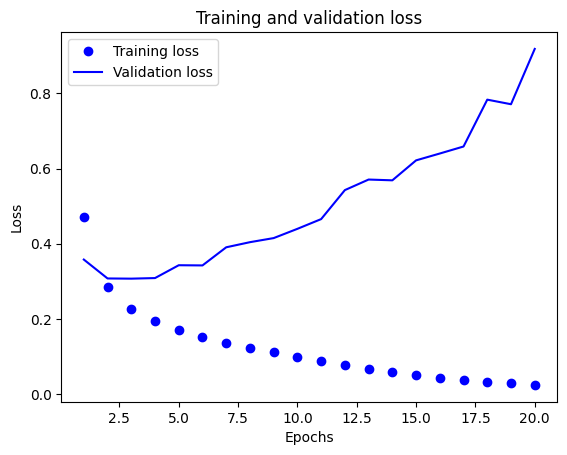

In [ ]:
import matplotlib.pyplot as plt

history_dict = history.history
history_dict.keys()


acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

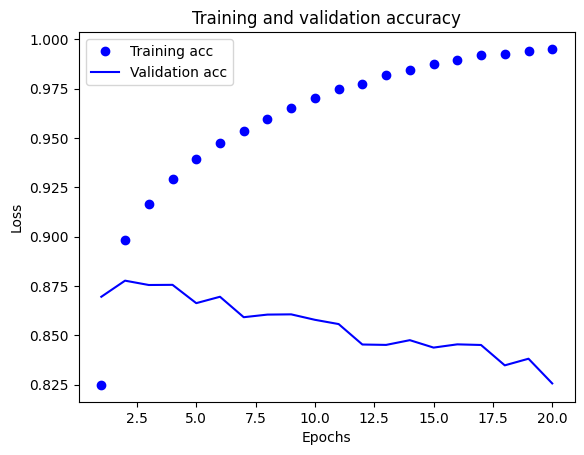

In [ ]:
plt.clf()   # clear figure
acc_values = history_dict['binary_accuracy']
val_acc_values = history_dict['val_binary_accuracy']

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


---

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.utils import shuffle

trn_texts,trn_labels = get_texts(PATH/'train')
tst_texts,tst_labels = get_texts(PATH/'test')

trn_texts = normalize_corpus(trn_texts)
tst_texts = normalize_corpus(tst_texts)

vocab_sz = 10000
tok = Tokenizer(num_words=vocab_sz, oov_token='UNK')
tok.fit_on_texts(trn_texts + tst_texts)

# Extract binary BoW features
x_train = tok.texts_to_matrix(trn_texts, mode='binary')
x_test = tok.texts_to_matrix(tst_texts, mode='binary')

y_train = np.asarray(trn_labels).astype('float32')
y_test = np.asarray(tst_labels).astype('float32')

# Shuffle the training data
x_train, y_train = shuffle(x_train, y_train, random_state=42)
x_test, y_test = shuffle(x_test, y_test, random_state=42)

In [ ]:
from keras import models
from keras import layers

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras import losses
from keras import metrics
from keras import optimizers

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])

history = model.fit(x_train,
                    y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_test, y_test))

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 251ms/step - binary_accuracy: 0.7124 - loss: 0.5855 - val_binary_accuracy: 0.8717 - val_loss: 0.3756
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - binary_accuracy: 0.8943 - loss: 0.3174 - val_binary_accuracy: 0.8797 - val_loss: 0.3049
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - binary_accuracy: 0.9218 - loss: 0.2297 - val_binary_accuracy: 0.8793 - val_loss: 0.2974
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step - binary_accuracy: 0.9293 - loss: 0.1995 - val_binary_accuracy: 0.8749 - val_loss: 0.3096
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 216ms/step - binary_accuracy: 0.9428 - loss: 0.1655 - val_binary_accuracy: 0.8716 - val_loss: 0.3234
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 196ms/step - binary_accuracy: 0.9512 - loss: 0.1495 - val_binary_accuracy: 0.8563 - val_loss: 0.3868
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - binary_accuracy: 0.9550 - loss: 0.1349 - val_binary_accuracy: 0.8653 - val_loss: 0.3639
Epo

# Counts (TF)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

vocab_sz = 10000 # None means all
tok = Tokenizer(num_words=vocab_sz,oov_token ='UNK') # intializing a tokenizer object
tok.fit_on_texts(texts) # fitting on the whole text train + test

x_train = tok.texts_to_matrix(trn_texts, mode='count')  # creating count matrix of training data
x_test = tok.texts_to_matrix(tst_texts, mode ='count') # similarily for test
print(x_train)
print(x_test)




[[ 0. 55.  5. ...  0.  0.  0.]
 [ 0.  4.  4. ...  0.  0.  0.]
 [ 0.  3.  0. ...  0.  0.  0.]
 ...
 [ 0. 52.  6. ...  0.  0.  0.]
 [ 0.  9.  4. ...  0.  0.  0.]
 [ 0. 31.  9. ...  0.  0.  0.]]
[[ 0. 11.  5. ...  0.  0.  0.]
 [ 0.  0.  3. ...  0.  0.  0.]
 [ 0. 43.  5. ...  0.  0.  0.]
 ...
 [ 0. 71.  2. ...  0.  0.  0.]
 [ 0. 56. 12. ...  0.  0.  0.]
 [ 0.  1.  0. ...  0.  0.  0.]]


In [ ]:
y_train = np.asarray(trn_labels).astype('float32')
y_test = np.asarray(tst_labels).astype('float32')

In [ ]:
from keras import losses
from keras import metrics
from keras import optimizers
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.summary()

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(x_train,
                    y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_test, y_test))

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 15s 283ms/step - binary_accuracy: 0.7471 - loss: 0.5488 - val_binary_accuracy: 0.8736 - val_loss: 0.3515
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - binary_accuracy: 0.9033 - loss: 0.2818 - val_binary_accuracy: 0.8686 - val_loss: 0.3357
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - binary_accuracy: 0.9196 - loss: 0.2219 - val_binary_accuracy: 0.8617 - val_loss: 0.3554
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 175ms/step - binary_accuracy: 0.9326 - loss: 0.1874 - val_binary_accuracy: 0.8725 - val_loss: 0.3260
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 189ms/step - binary_accuracy: 0.9437 - loss: 0.1610 - val_binary_accuracy: 0.8662 - val_loss: 0.3601
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - binary_accuracy: 0.9525 - loss: 0.1440 - val_binary_accuracy: 0.8685 - val_loss: 0.3621
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 196ms/step - binary_accuracy: 0.9589 - loss: 0.1248 - val_binary_accuracy: 0.8650 - val_loss: 0.3850
Epoc

In [ ]:
import matplotlib.pyplot as plt

history_dict = history.history
history_dict

{'binary_accuracy': [0.8202800154685974,
  0.9007599949836731,
  0.9186000227928162,
  0.9309599995613098,
  0.940559983253479,
  0.9478399753570557,
  0.9530799984931946,
  0.9587600231170654,
  0.9640799760818481,
  0.9684000015258789,
  0.9729200005531311,
  0.9747999906539917,
  0.9784799814224243,
  0.982479989528656,
  0.9833599925041199,
  0.9863600134849548,
  0.9877600073814392,
  0.9902399778366089,
  0.9912800192832947,
  0.9924799799919128],
 'loss': [0.45556434988975525,
  0.27566030621528625,
  0.22154513001441956,
  0.19077211618423462,
  0.16836018860340118,
  0.14963075518608093,
  0.1337982565164566,
  0.11962979286909103,
  0.1074671745300293,
  0.09813083708286285,
  0.08576186746358871,
  0.07772982865571976,
  0.06890236586332321,
  0.06132407858967781,
  0.05690043419599533,
  0.05024942383170128,
  0.04326191917061806,
  0.03766738250851631,
  0.033451441675424576,
  0.03080294467508793],
 'val_binary_accuracy': [0.8735600113868713,
  0.8685600161552429,
  0.861

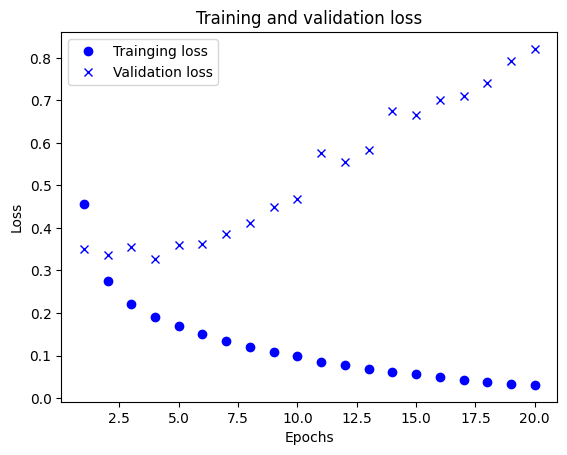

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1,len(acc)+1)

plt.plot(epochs, loss, 'bo', label = 'Trainging loss')
plt.plot(epochs , val_loss,'bx', label='Validation loss')
plt.title("Training and validation loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

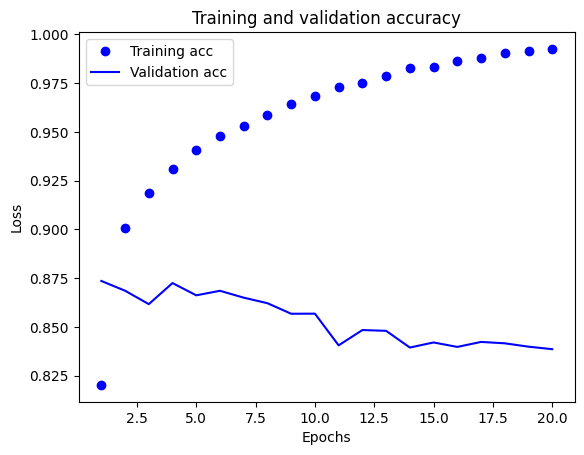

In [ ]:
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Frequency (Normalized)

In [ ]:

x_train = tok.texts_to_matrix(trn_texts, mode='freq')
x_test = tok.texts_to_matrix(tst_texts, mode='freq')


In [ ]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.summary()
model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])
history = model.fit(x_train,
                    y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_test, y_test))

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 336ms/step - binary_accuracy: 0.5254 - loss: 0.6928 - val_binary_accuracy: 0.5220 - val_loss: 0.6910
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 175ms/step - binary_accuracy: 0.5642 - loss: 0.6901 - val_binary_accuracy: 0.6740 - val_loss: 0.6869
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 181ms/step - binary_accuracy: 0.6649 - loss: 0.6855 - val_binary_accuracy: 0.6915 - val_loss: 0.6800
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 200ms/step - binary_accuracy: 0.6975 - loss: 0.6776 - val_binary_accuracy: 0.7217 - val_loss: 0.6691
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step - binary_accuracy: 0.7295 - loss: 0.6651 - val_binary_accuracy: 0.7639 - val_loss: 0.6539
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step - binary_accuracy: 0.7614 - loss: 0.6487 - val_binary_accuracy: 0.7744 - val_loss: 0.6334
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 177ms/step - binary_accuracy: 0.7777 - loss: 0.6263 - val_binary_accuracy: 0.7888 - val_loss: 0.6082
Epo

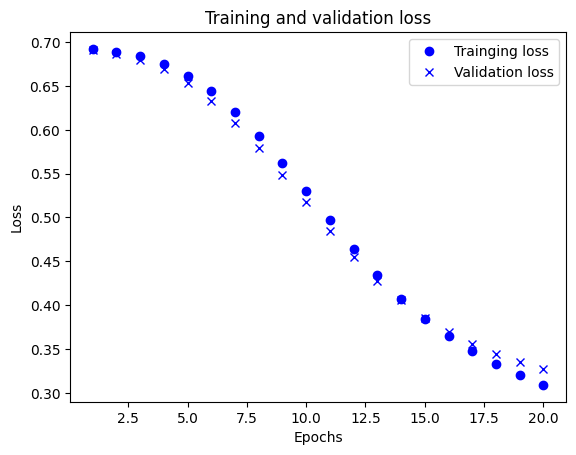

In [ ]:
acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1,len(acc)+1)

plt.plot(epochs, loss, 'bo', label = 'Trainging loss')
plt.plot(epochs , val_loss,'bx', label='Validation loss')
plt.title("Training and validation loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

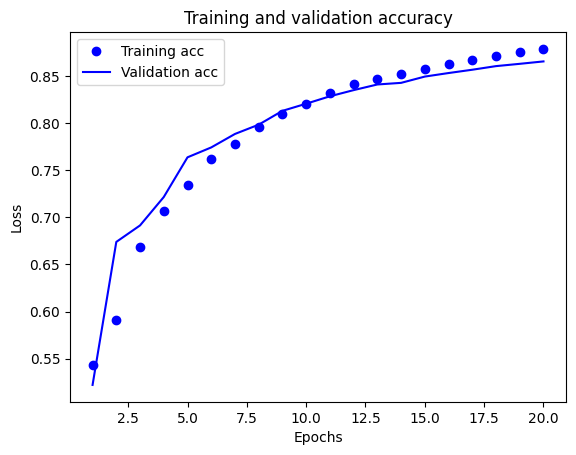

In [ ]:
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# TF-IDF

In [ ]:
x_train = tok.texts_to_matrix(trn_texts, mode='tfidf')
x_test = tok.texts_to_matrix(tst_texts, mode='tfidf')

In [ ]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.summary()
model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])
history = model.fit(x_train,
                    y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_test, y_test))

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 252ms/step - binary_accuracy: 0.7351 - loss: 0.5285 - val_binary_accuracy: 0.8728 - val_loss: 0.3330
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - binary_accuracy: 0.9267 - loss: 0.2186 - val_binary_accuracy: 0.8633 - val_loss: 0.3482
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - binary_accuracy: 0.9509 - loss: 0.1513 - val_binary_accuracy: 0.8643 - val_loss: 0.3627
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - binary_accuracy: 0.9667 - loss: 0.1081 - val_binary_accuracy: 0.8583 - val_loss: 0.4123
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - binary_accuracy: 0.9774 - loss: 0.0792 - val_binary_accuracy: 0.8527 - val_loss: 0.4717
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - binary_accuracy: 0.9845 - loss: 0.0565 - val_binary_accuracy: 0.8497 - val_loss: 0.5285
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - binary_accuracy: 0.9902 - loss: 0.0420 - val_binary_accuracy: 0.8462 - val_loss: 0.5832
Epoch

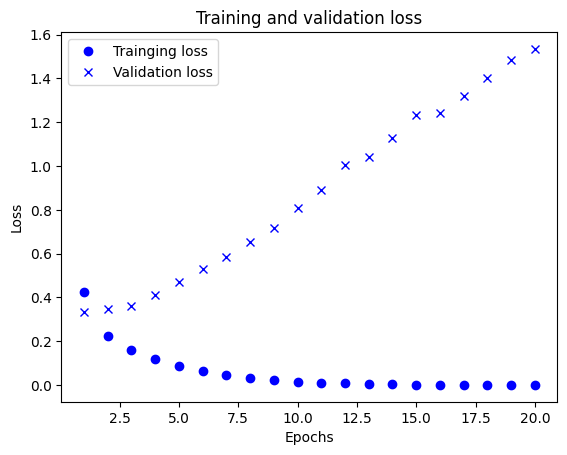

In [ ]:
acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1,len(acc)+1)

plt.plot(epochs, loss, 'bo', label = 'Trainging loss')
plt.plot(epochs , val_loss,'bx', label='Validation loss')
plt.title("Training and validation loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

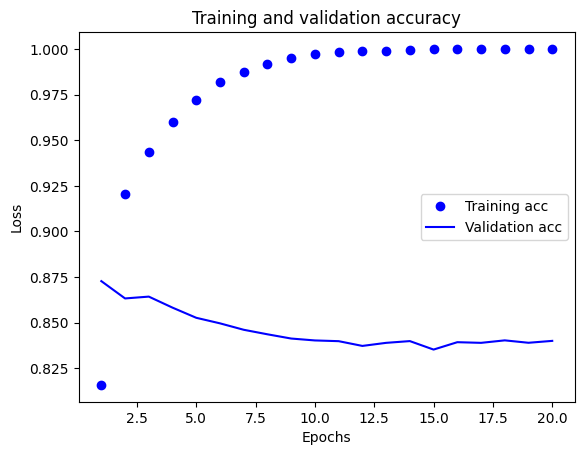

In [ ]:
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# TF-IDF implementation using Scikit-learn

**Documentation**
https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [ ]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
)


In [ ]:
X = vectorizer.fit_transform(trn_texts)

In [ ]:
import pandas as pd
features = vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(X.toarray(), columns=features)
df_tfidf

,aag,aaron,abandon,abbey,abbot,abbott,abc,abduct,abe,abhay,...,zizeks,zodiac,zoe,zombi,zombie,zone,zoo,zoom,zorro,zu
0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.14506,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24996,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24997,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24998,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X_test = vectorizer.transform(tst_texts)
pd.DataFrame(X_test.toarray(), columns=features)

,aag,aaron,abandon,abbey,abbot,abbott,abc,abduct,abe,abhay,...,zizeks,zodiac,zoe,zombi,zombie,zone,zoo,zoom,zorro,zu
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.summary()
model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])
history = model.fit(X,
                    y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(X_test, y_test))

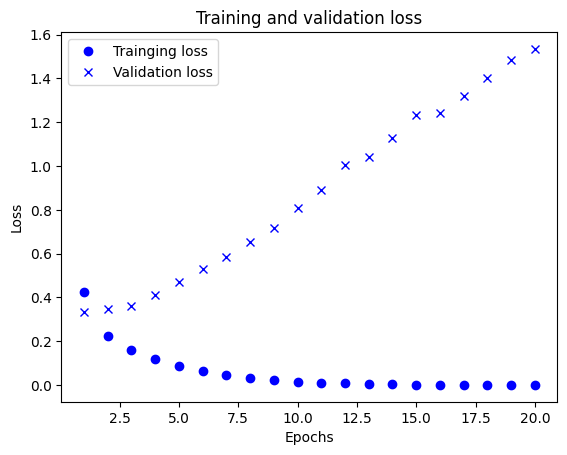

In [ ]:
acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1,len(acc)+1)

plt.plot(epochs, loss, 'bo', label = 'Trainging loss')
plt.plot(epochs , val_loss,'bx', label='Validation loss')
plt.title("Training and validation loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

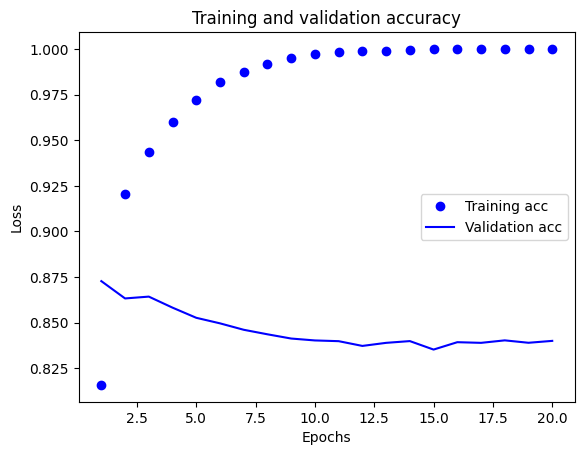

In [ ]:
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()